## Superstore Data Analysis Python Project

## Objective:
Analyze sales, profit, customer behavior, discount impact,
and operational performance using Python.

## Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn

## Dataset:
Sample Superstore Dataset

## Business Problem

## Importing Required Libraries

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Reading the CSV File

In [4]:
data = pd.read_csv(r"C:\superstoore\Sample - Superstore.csv", encoding="latin1")

## .head()

In [6]:
data.head(4)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310


## Data Cleaning

In [21]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [22]:
data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [10]:
data.shape

(9994, 21)

In [12]:
data.count()

Row ID           9994
Order ID         9994
Order Date       9994
Ship Date        9994
Ship Mode        9994
Customer ID      9994
Customer Name    9994
Segment          9994
Country          9994
City             9994
State            9994
Postal Code      9994
Region           9994
Product ID       9994
Category         9994
Sub-Category     9994
Product Name     9994
Sales            9994
Quantity         9994
Discount         9994
Profit           9994
dtype: int64

In [26]:
data.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [24]:
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


## • How many unique customers, products, and orders are there? 

In [33]:
data[['Customer ID', 'Product ID', 'Order ID']].nunique()

Customer ID     793
Product ID     1862
Order ID       5009
dtype: int64

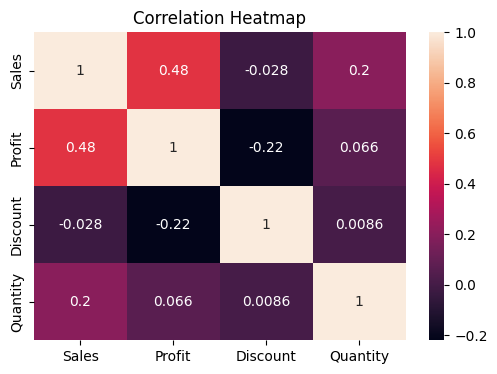

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(
    data[['Sales','Profit','Discount','Quantity']].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

## Sales & Profit Analysis

## • What is the total sales, profit, and quantity? 

In [37]:
totals = data[['Sales', 'Profit', 'Quantity']].sum().round(2)

print("Total Sales :", totals['Sales'])
print("Total Profit :", totals['Profit'])
print("Total Quantity :", totals['Quantity'])

Total Sales : 2297200.86
Total Profit : 286397.02
Total Quantity : 37873.0


## • Which region generates the highest sales? 

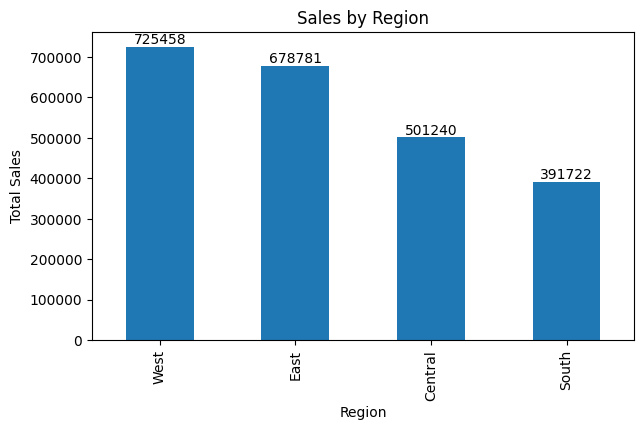

In [13]:
plt.figure(figsize=(7,4))

region_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)

ax = region_sales.plot(kind='bar')

plt.bar_label(ax.containers[0], fmt='%.0f')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

## • Which city gives maximum sales? 

In [125]:
max_city_sale = data.groupby('City')['Sales'].sum()

print('Maximum Sales City :', max_city_sale.idxmax())
print('Maximum Sales Amount :', max_city_sale.max())

Maximum Sales City : New York City
Maximum Sales Amount : 256368.161


## • Which state is most profitable / loss-making? 

In [123]:
state_profit = data.groupby('State')['Profit'].sum()

print("Most Profitable State :", state_profit.idxmax())
print("Highest Profit Amount :", round(state_profit.max(), 2))

print("Most Loss-Making State :", state_profit.idxmin())
print("Lowest Profit Amount :", round(state_profit.min(), 2))

Most Profitable State : California
Highest Profit Amount : 76381.39
Most Loss-Making State : Texas
Lowest Profit Amount : -25729.36


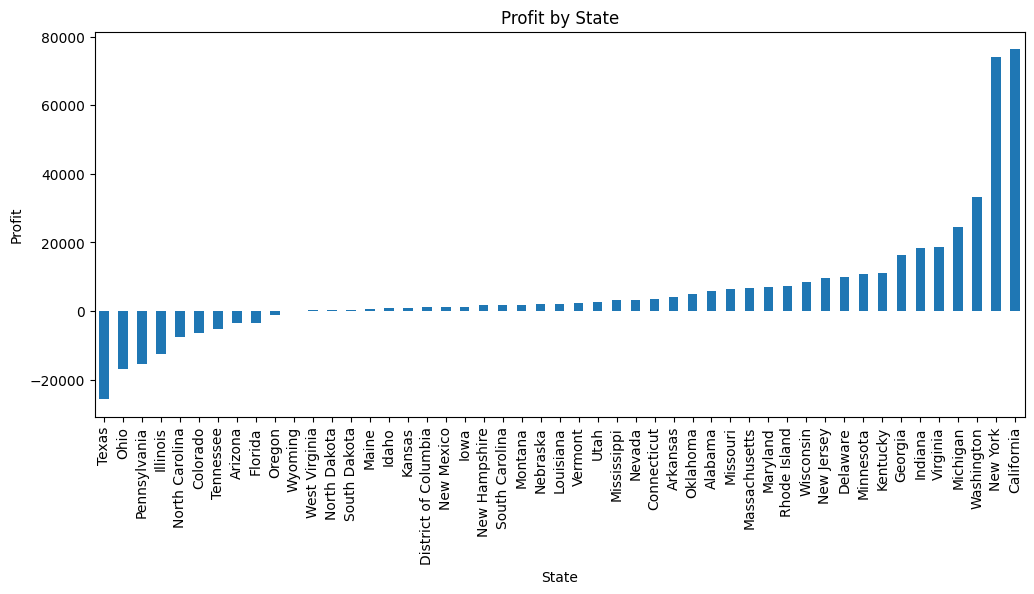

In [14]:
plt.figure(figsize=(12,5))

state_profit = data.groupby('State')['Profit'].sum().sort_values()

state_profit.plot(kind='bar')

plt.title("Profit by State")
plt.xlabel("State")
plt.ylabel("Profit")

plt.show()

## Profit Margin Analysis

In [25]:
data['Profit Margin %'] = (data['Profit'] / data['Sales']) * 100

margin = data['Profit Margin %'].mean()

print("Average Profit Margin :", round(margin, 2))

Average Profit Margin : 12.03


## Category & Sub-Category Analysis

## • Which category (Furniture, Office Supplies, Technology) has highest sales? 

In [23]:
data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

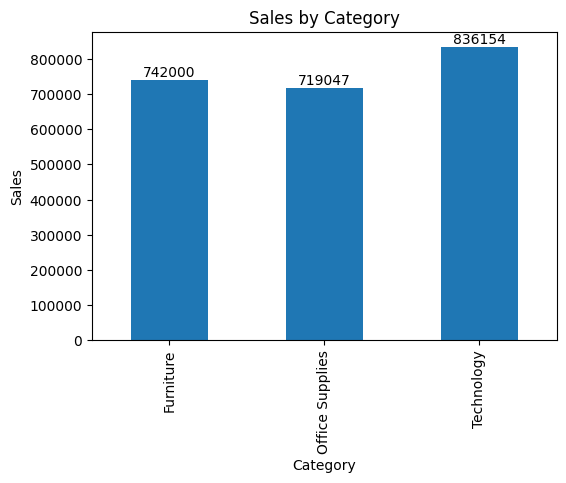

In [15]:
plt.figure(figsize=(6,4))

category_sales = data.groupby('Category')['Sales'].sum()

ax = category_sales.plot(kind='bar')

plt.bar_label(ax.containers[0], fmt='%.0f')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

## • Which sub-category is most sold? 

In [166]:
data.groupby('Sub-Category')[['Quantity', 'Sales']].sum().sort_values(by='Quantity', ascending=False)

,Quantity,Sales
Sub-Category,,
Binders,5974,203412.7330
Paper,5178,78479.2060
Furnishings,3563,91705.1640
Phones,3289,330007.0540
Storage,3158,223843.6080
Art,3000,27118.7920
Accessories,2976,167380.3180
Chairs,2356,328449.1030
Appliances,1729,107532.1610


In [137]:
category = data.groupby('Sub-Category')['Sales'].sum()

print('Highest Profit Sub-Category :', (category.idxmax()))
print('Profit Amount :', round(category.max(),2))

Highest Profit Sub-Category : Phones
Profit Amount : 330007.05


## • Which sub-category is most loss-making? 

In [150]:
category = data.groupby('Sub-Category')['Profit'].sum()

print('Most Loss-Making Sub-Category :', category.idxmin())
print('Lowest Profit Amount :', round(category.min(), 2))

Most Loss-Making Sub-Category : Tables
Lowest Profit Amount : -17725.48


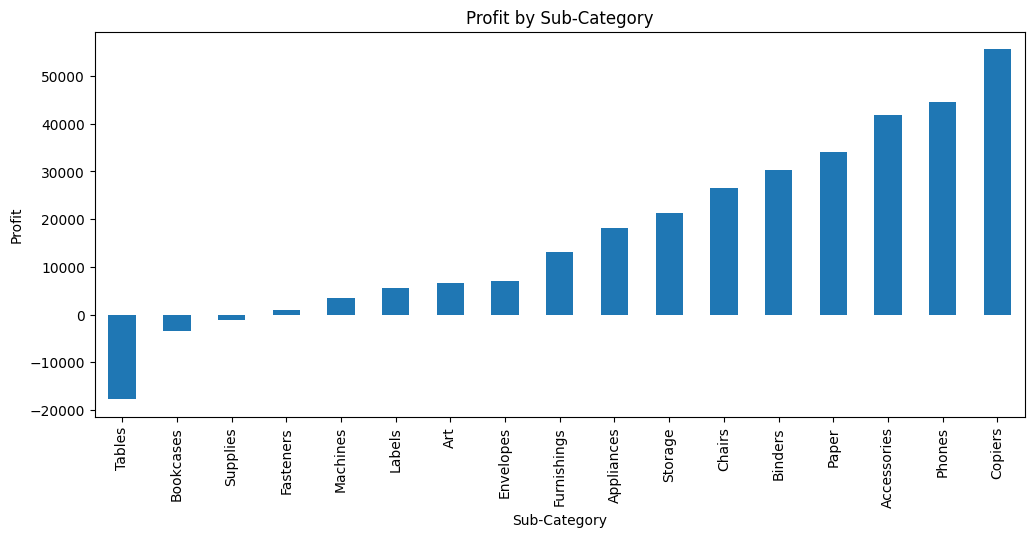

In [16]:
plt.figure(figsize=(12,5))

sub_profit = data.groupby('Sub-Category')['Profit'].sum().sort_values()

sub_profit.plot(kind='bar')

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.show()

## • Which sub-category has highest discount impact? 

In [163]:
data.groupby('Sub-Category')[['Discount', 'Profit']].sum().sort_values(by='Discount', ascending=False)

,Discount,Profit
Sub-Category,,
Binders,567.00,30221.7633
Phones,137.40,44515.7306
Furnishings,132.40,13059.1436
Chairs,105.00,26590.1663
Paper,102.60,34053.5693
Tables,83.35,-17725.4811
Appliances,77.60,18138.0054
Storage,63.20,21278.8264
Accessories,60.80,41936.6357


In [159]:
sub_category = data.groupby('Sub-Category')['Discount'].sum()

print('Highest Discount on Sub-Category :', sub_category.idxmax())
print('Highest Discount Amount :', sub_category.max())

Highest Discount on Sub-Category : Binders
Highest Discount Amount : 567.0


## Customer Analysis

## • Who are the top 10 customers by sales? 

In [172]:
customers = data.groupby(['Customer ID', 'Customer Name'])['Sales'].sum().sort_values(ascending=False).head(10)
print(customers)


Customer ID  Customer Name     
SM-20320     Sean Miller           25043.050
TC-20980     Tamara Chand          19052.218
RB-19360     Raymond Buch          15117.339
TA-21385     Tom Ashbrook          14595.620
AB-10105     Adrian Barton         14473.571
KL-16645     Ken Lonsdale          14175.229
SC-20095     Sanjit Chand          14142.334
HL-15040     Hunter Lopez          12873.298
SE-20110     Sanjit Engle          12209.438
CC-12370     Christopher Conant    12129.072
Name: Sales, dtype: float64


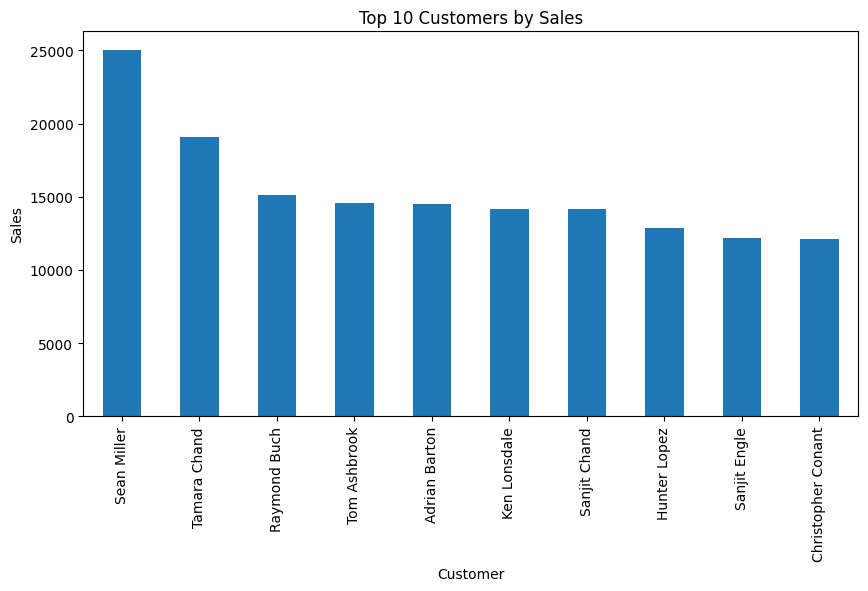

In [21]:
top_customers = data.groupby('Customer Name')['Sales'].sum()\
                    .sort_values(ascending=False)\
                    .head(10)

plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.show()

## • Who are the most profitable customers? 

In [177]:
customers = data.groupby(['Customer ID', 'Customer Name'])['Profit'].sum().sort_values(ascending=False).head(1)
print(customers)

Customer ID  Customer Name
TC-20980     Tamara Chand     8981.3239
Name: Profit, dtype: float64


## Among the customer segments (Consumer, Corporate, and Home Office), which segment buys the most?

In [180]:
segment = data.groupby('Segment')['Sales'].sum()

print('Highest Buying Segment :', segment.idxmax())
print('Sales Amount :', round(segment.max(), 2))

Highest Buying Segment : Consumer
Sales Amount : 1161401.34


## • Which segment is most profitable? 

In [181]:
segment = data.groupby('Segment')['Profit'].sum()

print('Highest Profitable Segment :', segment.idxmax())
print('Profit Amount :', round(segment.max(), 2))

Highest Profitable Segment : Consumer
Profit Amount : 134119.21


## Product Analysis

## • Which product has the highest sales? 


In [185]:
product = data.groupby('Product Name')['Sales'].sum()

print('Highest Product Sales :', product.idxmax())
print('Amount :', round(product.max(), 2))

Highest Product Sales : Canon imageCLASS 2200 Advanced Copier
Amount : 61599.82


## • Which product is giving loss despite high sales?  

In [189]:
product = data.groupby('Product Name')[['Sales', 'Profit']].sum()

loss_product = product.sort_values(by='Profit').head(1)

print(loss_product)

                                               Sales     Profit
Product Name                                                   
Cubify CubeX 3D Printer Double Head Print  11099.963 -8879.9704


## • Which product is most frequently ordered? 

In [197]:
product = data['Product Name'].value_counts()

print('Most Frequently Ordered Product :', product.idxmax())
print('Number of Orders :', product.max())

Most Frequently Ordered Product : Staple envelope
Number of Orders : 48


## • Which products should be discontinued? 

In [200]:
least_products = data['Product Name'].value_counts().sort_values().head(10)

print("Top 10 Least Ordered Products:")
print(least_products)

Product Name
Eldon Jumbo ProFile Portable File Boxes Graphite/Black    1
LG G2                                                     1
Eureka Hand Vacuum, Bagless                               1
Cisco 8961 IP Phone Charcoal                              1
Acco Glide Clips                                          1
Xerox 1901                                                1
Memorex Mini Travel Drive 4 GB USB 2.0 Flash Drive        1
Jiffy Padded Mailers with Self-Seal Closure               1
Hewlett-Packard Deskjet 5550 Printer                      1
Avaya IP Phone 1140E VoIP phone                           1
Name: count, dtype: int64


## Discount Analysis

## • How does discount affect profit? 

In [204]:
discount_effect = data.groupby('Discount')['Profit'].mean().sort_values(ascending=True)
print(discount_effect)

Discount
0.50   -310.703456
0.45   -226.646464
0.40   -111.927429
0.80   -101.796797
0.70    -95.874060
0.32    -88.560656
0.30    -45.679636
0.60    -43.077212
0.20     24.702572
0.15     27.288298
0.00     66.900292
0.10     96.055074
Name: Profit, dtype: float64


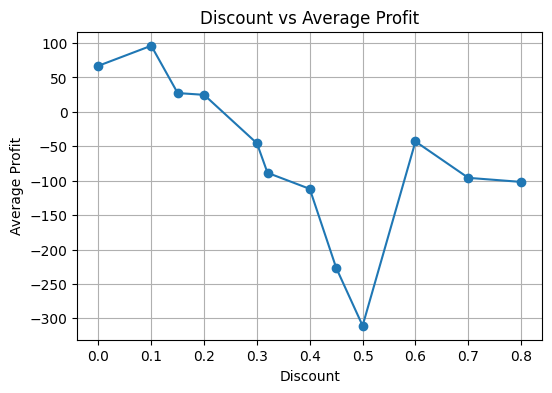

In [17]:
plt.figure(figsize=(6,4))

discount_profit = data.groupby('Discount')['Profit'].mean()

plt.plot(discount_profit.index,
         discount_profit.values,
         marker='o')

plt.title("Discount vs Average Profit")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

## • Do high discounts always increase sales? 

In [216]:
discount_affect = data.groupby('Discount')['Sales'].mean()
print(discount_affect)

Discount
0.00    226.742074
0.10    578.397351
0.15    529.971567
0.20    209.076940
0.30    454.742974
0.32    536.794770
0.40    565.134874
0.45    498.634000
0.50    892.705152
0.60     48.150000
0.70     97.177708
0.80     56.545853
Name: Sales, dtype: float64


## • Which discount range gives maximum profit? 

In [222]:
discount_affect = data.groupby('Discount')['Profit'].mean()
print(discount_affect)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


In [224]:
discount_profit = data.groupby('Discount')['Profit'].mean()

best_discount = discount_profit.idxmax()
best_profit = discount_profit.max()

print("Best Discount:", best_discount)
print("Max Profit:", best_profit)

Best Discount: 0.1
Max Profit: 96.05507446808511


## • Which products are affected negatively by discount? 

In [230]:
product_discount_profit = data.groupby('Product Name')[['Discount', 'Profit']].mean()
print(product_discount_profit.sort_values('Profit'))

                                                    Discount       Profit
Product Name                                                             
Cubify CubeX 3D Printer Triple Head Print           0.500000 -3839.990400
Cubify CubeX 3D Printer Double Head Print           0.533333 -2959.990133
Cisco TelePresence System EX90 Videoconferencin...  0.500000 -1811.078400
Lexmark MX611dhe Monochrome Laser Printer           0.400000 -1147.493250
Zebra GK420t Direct Thermal/Thermal Transfer Pr...  0.700000  -938.280000
...                                                      ...          ...
Zebra ZM400 Thermal Label Printer                   0.000000  1671.768000
3D Systems Cube Printer, 2nd Generation, Magenta    0.000000  1858.985700
Ativa V4110MDD Micro-Cut Shredder                   0.000000  1886.473050
Canon imageCLASS MF7460 Monochrome Digital Lase...  0.000000  1995.990000
Canon imageCLASS 2200 Advanced Copier               0.120000  5039.985600

[1850 rows x 2 columns]


In [231]:
loss_products = product_discount_profit[product_discount_profit['Profit'] < 0]
print(loss_products.sort_values('Profit'))

                                                    Discount        Profit
Product Name                                                              
Cubify CubeX 3D Printer Triple Head Print           0.500000 -3.839990e+03
Cubify CubeX 3D Printer Double Head Print           0.533333 -2.959990e+03
Cisco TelePresence System EX90 Videoconferencin...  0.500000 -1.811078e+03
Lexmark MX611dhe Monochrome Laser Printer           0.400000 -1.147493e+03
Zebra GK420t Direct Thermal/Thermal Transfer Pr...  0.700000 -9.382800e+02
...                                                      ...           ...
Eldon Gobal File Keepers                            0.066667 -1.009333e-01
Rubber Band Ball                                    0.050000 -7.480000e-02
Acco PRESSTEX Data Binder with Storage Hooks, D...  0.550000 -4.035000e-02
Premier Electric Letter Opener                      0.075000 -8.881784e-16
Global Super Steno Chair                            0.142857 -2.537653e-16

[301 rows x 2 columns]


## Shipping Analysis

## • Which shipping mode is most used? 

In [258]:
shipping_mode = data['Ship Mode'].value_counts()

print('Most shipping mode Used is :', shipping_mode.idxmax())
print('Count of shipping mode :', shipping_mode.max())

Most shipping mode Used is : Standard Class
Count of shipping mode : 5968


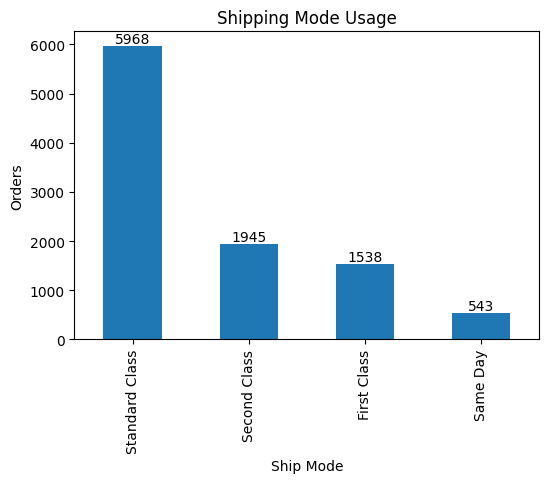

In [19]:
plt.figure(figsize=(6,4))

ax = data['Ship Mode'].value_counts().plot(kind='bar')

plt.bar_label(ax.containers[0])

plt.title("Shipping Mode Usage")
plt.xlabel("Ship Mode")
plt.ylabel("Orders")

plt.show()

## • Which shipping mode gives highest profit? 

In [262]:
profit = data.groupby('Ship Mode')['Profit'].sum()

print("Highest Profit by Shipping Mode :", profit.idxmax())
print("Max Profit:", round(profit.max(),2))

Highest Profit by Shipping Mode : Standard Class
Max Profit: 164088.79


## Time-Based Analysis 

## • Which month has highest sales? 

In [9]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [10]:
data['Month'] = data['Order Date'].dt.month

In [12]:
monthly_sales = data.groupby('Month')['Sales'].sum()

highest_month_sale = monthly_sales.idxmax()
highest_sale_amount = monthly_sales.max()

print("Highest Sales Month :", highest_month_sale)
print("Highest Month Sale Amount :", round(highest_sale_amount, 2))

Highest Sales Month : 11
Highest Month Sale Amount : 352461.07


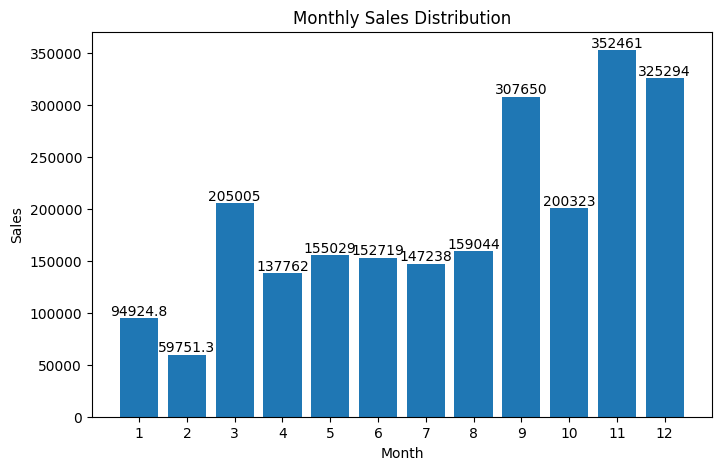

In [316]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(monthly_sales.index, monthly_sales.values)

ax.bar_label(bars)

ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.set_title("Monthly Sales Distribution")

ax.set_xticks(range(1, 13))

plt.show()

## 	• Which year had maximum profit? 

In [313]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [314]:
data['year'] = data['Order Date'].dt.year

In [315]:
yearly_sales = data.groupby('year')['Profit'].sum().sort_values(ascending=False).head(1)
print(yearly_sales)

year
2017    93439.2696
Name: Profit, dtype: float64


## • Is sales increasing or decreasing over time? 

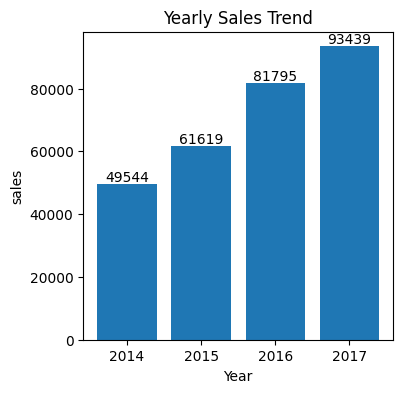

In [32]:
year = [2014, 2015, 2016, 2017]
profits = [49543.9741, 61618.6037, 81795.1743, 93439.2696]

plt.figure(figsize=(4, 4))

bars = plt.bar(year, profits)

plt.bar_label(bars, fmt="%.0f")

plt.xlabel("Year")
plt.ylabel("sales")
plt.title("Yearly Sales Trend")

plt.xticks(year)

plt.show()

## • Seasonal trend in sales (festival effect) 

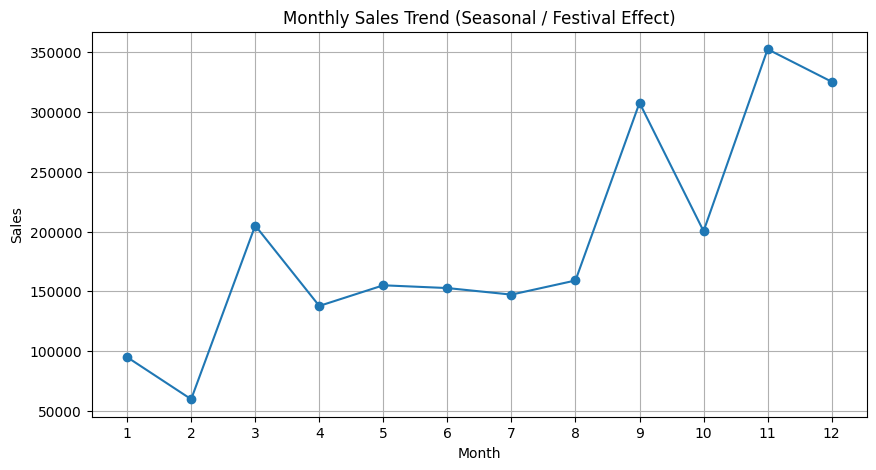

In [338]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend (Seasonal / Festival Effect)")
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

## Geography Insights

## 	• Which region performs best overall? 


In [350]:
region = data.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
print(region)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


In [349]:
region.head(1)

,Sales,Profit
Region,,
West,725457.8245,108418.4489


## • Which state has highest sales but low profit? 


In [353]:
state = data.groupby('State')[['Sales', 'Profit']].sum()

result = state[(state['Sales'] > state['Sales'].mean()) & 
               (state['Profit'] < state['Profit'].mean())]

print(result.sort_values(by='Sales', ascending=False))

                      Sales      Profit
State                                  
Texas           170188.0458 -25729.3563
Pennsylvania    116511.9140 -15559.9603
Florida          89473.7080  -3399.3017
Illinois         80166.1010 -12607.8870
Ohio             78258.1360 -16971.3766
North Carolina   55603.1640  -7490.9122


## • Which city is most loss-making? 


In [356]:
city = data.groupby('City')['Profit'].sum().sort_values(ascending=True)

print("Most Loss-Making City:")
print(city.head(1))

Most Loss-Making City:
City
Philadelphia   -13837.7674
Name: Profit, dtype: float64


## Business Insights

## • What are the top 5 reasons for loss in this business? 


The major causes of loss in the business are high discounting, inefficient shipping costs, specific loss-making cities, low-margin product categories, and poor pricing strategy. These factors result in situations where high sales do not translate into profit.

## • Which products should company promote? 


In [359]:
products = data.groupby('Product Name')[['Sales', 'Profit']].sum()

best_products = products.sort_values(by='Profit', ascending=False)

print(best_products.head(10))

                                                        Sales      Profit
Product Name                                                             
Canon imageCLASS 2200 Advanced Copier               61599.824  25199.9280
Fellowes PB500 Electric Punch Plastic Comb Bind...  27453.384   7753.0390
Hewlett Packard LaserJet 3310 Copier                18839.686   6983.8836
Canon PC1060 Personal Laser Copier                  11619.834   4570.9347
HP Designjet T520 Inkjet Large Format Printer -...  18374.895   4094.9766
Ativa V4110MDD Micro-Cut Shredder                    7699.890   3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta    14299.890   3717.9714
Plantronics Savi W720 Multi-Device Wireless Hea...   9367.290   3696.2820
Ibico EPK-21 Electric Binding System                15875.916   3345.2823
Zebra ZM400 Thermal Label Printer                    6965.700   3343.5360


## 	• Where should company reduce discount? 


In [361]:
discount_area = data.groupby('State')[['Discount', 'Profit', 'Sales']].mean()

print(discount_area.sort_values(by='Profit'))

                      Discount      Profit        Sales
State                                                  
Ohio                  0.324947  -36.186304   166.861697
Colorado              0.316484  -35.867351   176.418231
North Carolina        0.283534  -30.083985   223.305880
Tennessee             0.291257  -29.189583   167.551219
Pennsylvania          0.328620  -26.507598   198.487077
Texas                 0.370193  -26.121174   172.779742
Illinois              0.390041  -25.625787   162.939230
Arizona               0.303571  -15.303235   157.508933
Oregon                0.288710   -9.600569   140.573790
Florida               0.299347   -8.875461   233.612815
New Mexico            0.059459   31.273408   129.284378
North Dakota          0.000000   32.878529   131.415714
South Dakota          0.000000   32.902358   109.630000
Kansas                0.000000   34.851813   121.429583
California            0.072764   38.171608   228.729451
Idaho                 0.085714   39.367767   208

In [362]:
risk_states = discount_area[(discount_area['Discount'] > discount_area['Discount'].mean()) &
                            (discount_area['Profit'] < 0)]

print(risk_states.sort_values(by='Profit'))

                Discount     Profit       Sales
State                                          
Ohio            0.324947 -36.186304  166.861697
Colorado        0.316484 -35.867351  176.418231
North Carolina  0.283534 -30.083985  223.305880
Tennessee       0.291257 -29.189583  167.551219
Pennsylvania    0.328620 -26.507598  198.487077
Texas           0.370193 -26.121174  172.779742
Illinois        0.390041 -25.625787  162.939230
Arizona         0.303571 -15.303235  157.508933
Oregon          0.288710  -9.600569  140.573790
Florida         0.299347  -8.875461  233.612815


## 	• Which region should company expand? 


In [364]:
region = data.groupby('Region')[['Sales', 'Profit']].sum()

region = region.sort_values(by='Profit', ascending=False)

print(region)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


In [365]:
region['Profit Margin'] = region['Profit'] / region['Sales'] * 100

print(region.sort_values(by='Profit Margin', ascending=False))

               Sales       Profit  Profit Margin
Region                                          
West     725457.8245  108418.4489      14.944831
East     678781.2400   91522.7800      13.483399
South    391721.9050   46749.4303      11.934342
Central  501239.8908   39706.3625       7.921629


## 	• What is the most profitable strategy combination? 


In [366]:
combo = data.groupby(['Segment', 'Region'])[['Sales', 'Profit']].sum()

best_combo = combo.sort_values(by='Profit', ascending=False)

print(best_combo.head(10))

                           Sales      Profit
Segment     Region                          
Consumer    West     362880.7730  57450.6040
            East     350908.1670  41190.9843
Corporate   West     225855.2745  34437.4299
Consumer    South    195580.9710  26913.5728
Home Office East     127463.7260  26709.2168
Corporate   East     200409.3470  23622.5789
            Central  157995.8128  18703.9020
Home Office West     136721.7770  16530.4150
Corporate   South    121885.9325  15215.2232
Home Office Central   91212.6440  12438.4124


In [367]:
cat_combo = data.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum()

best_cat = cat_combo.sort_values(by='Profit', ascending=False)

print(best_cat.head(10))

                                   Sales      Profit
Category        Sub-Category                        
Technology      Copiers       149528.030  55617.8249
                Phones        330007.054  44515.7306
                Accessories   167380.318  41936.6357
Office Supplies Paper          78479.206  34053.5693
                Binders       203412.733  30221.7633
Furniture       Chairs        328449.103  26590.1663
Office Supplies Storage       223843.608  21278.8264
                Appliances    107532.161  18138.0054
Furniture       Furnishings    91705.164  13059.1436
Office Supplies Envelopes      16476.402   6964.1767


In [368]:
ship = data.groupby('Ship Mode')[['Sales', 'Profit']].sum()

print(ship.sort_values(by='Profit', ascending=False))

                       Sales       Profit
Ship Mode                                
Standard Class  1.358216e+06  164088.7875
Second Class    4.591936e+05   57446.6354
First Class     3.514284e+05   48969.8399
Same Day        1.283631e+05   15891.7589


In [369]:
discount_strategy = data.groupby('Discount')[['Sales', 'Profit']].sum()

print(discount_strategy.sort_values(by='Profit', ascending=False))

                 Sales       Profit
Discount                           
0.00      1.087908e+06  320987.6032
0.20      7.645944e+05   90337.3060
0.10      5.436935e+04    9029.1770
0.15      2.755852e+04    1418.9915
0.32      1.449346e+04   -2391.1377
0.45      5.484974e+03   -2493.1111
0.60      6.644700e+03   -5944.6552
0.30      1.032267e+05  -10369.2774
0.50      5.891854e+04  -20506.4281
0.40      1.164178e+05  -23057.0504
0.80      1.696376e+04  -30539.0392
0.70      4.062028e+04  -40075.3569


## KPI Summary

In [27]:
# Total Sales
total_sales = round(data['Sales'].sum(), 2)

# Total Profit
total_profit = round(data['Profit'].sum(), 2)

# Profit Margin
profit_margin = round((total_profit / total_sales) * 100, 2)

# Total Orders
total_orders = data['Order ID'].nunique()

# Total Customers
total_customers = data['Customer ID'].nunique()

# Best Region (Highest Profit)
best_region = data.groupby('Region')['Profit'].sum().idxmax()

# Worst State (Lowest Profit)
worst_state = data.groupby('State')['Profit'].sum().idxmin()


print("===== KPI SUMMARY =====")

print("Total Sales :", total_sales)
print("Total Profit :", total_profit)
print("Profit Margin :", profit_margin, "%")
print("Total Orders :", total_orders)
print("Total Customers :", total_customers)
print("Best Region :", best_region)
print("Worst State :", worst_state)

===== KPI SUMMARY =====
Total Sales : 2297200.86
Total Profit : 286397.02
Profit Margin : 12.47 %
Total Orders : 5009
Total Customers : 793
Best Region : West
Worst State : Texas


## Recommendations
Based on the analysis of the Superstore dataset, several strategic recommendations can help improve overall business performance and profitability.

1. Reduce Excessive Discounts

High discounts were one of the major reasons for negative profits in several products and regions. The company should carefully control discount rates, especially in low-profit areas.

2. Focus on High-Profit Categories

The Technology category generated strong profits compared to other categories. The business should increase promotion, inventory, and marketing efforts for high-performing products.

3. Improve Performance in Loss-Making Cities

Cities such as Philadelphia showed significant losses. The company should analyze operational costs, pricing strategies, and customer demand in these areas.

4. Optimize Shipping Strategy

Standard Class shipping mode generated the highest profit. The business should optimize shipping operations to reduce delivery costs while maintaining customer satisfaction.

5. Increase Marketing During Peak Sales Months

Sales performance was highest during November and December. The company should launch seasonal campaigns and promotional offers during these months to maximize revenue.

6. Monitor Products with High Sales but Low Profit

Some products generated strong sales but low or negative profit margins. These products should be re-evaluated for pricing, discounts, and operational costs.

Based on the analysis, the following business recommendations were provided:

## Conclusion

This project demonstrates practical business analysis using Python and data visualization techniques. The analysis successfully identified important sales trends, profit patterns, operational issues, and business opportunities.